In [1]:
"""
Q-G-CTGAN: Quality-Aware Cluster-Conditioned Oversampling
via Intra-Cluster Synthetic Sample Filtering

Notebook 07: Computational Efficiency Analysis

Addresses Reviewer #1 (R1-6): the original manuscript did not report
runtime, scalability, or computational complexity comparisons across
oversampling methods. This notebook aggregates timing data already
collected in Notebooks 02-04 into a unified comparison, covering:
  - Non-generative baselines (SMOTE, ADASYN, G-SMOTE): Notebook 02
  - Q-G-CTGAN (proposed): Notebook 03, broken down by pipeline stage
    (GMM clustering, CTGAN training, candidate generation, Stage 1
    filtering, Stage 2 MMD selection)
  - New generative baselines (K-means CTGAN, CTGAN-MOS, ctdGAN,
    CTAB-GAN+): Notebooks 04a-04c

NOTE ON METRIC GRANULARITY: Notebook 02's protocol recorded only a
single combined time_total_sec per fold (oversampling + classifier
training combined), since it predates the more detailed breakdown
introduced for Q-G-CTGAN and the new generative baselines. This is
disclosed explicitly rather than estimating a synthetic split.

NOTE ON CTAB-GAN+ EXCLUDED DATASETS: for the 3 datasets excluded from
Notebook 04c due to computational infeasibility (fraud_detection,
protein_homo, unsw_nb15), PROJECTED runtimes (not measured) from the
linear screening model (Notebook 04c) are reported and clearly marked
as projections, since measuring them directly was the infeasibility
being demonstrated. ecoli is also excluded from CTAB-GAN+'s timing
comparison, but for a different reason (structural instability, not
runtime) -- see Notebook 04c.

Reads  : ./results/02_baseline_results_scaled.csv
         ./results/03_qgctgan_results.csv
         ./results/04a_new_baselines_results.csv
         ./results/04b_ctdgan_results.csv
         ./results/04c_ctabganplus_results.csv
Writes : ./results/07_*.csv / *.png / *.pdf
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

RESULTS_DIR = "./results"

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 10,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})

DATASET_ORDER = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality", "ecoli",
    "pageblocks", "protein_homo",
    "satellite", "churn", "secom", "thyroid_sick", "unsw_nb15",
]

METHOD_LABELS = {
    "None": "None", "SMOTE": "SMOTE", "ADASYN": "ADASYN", "G-SMOTE": "G-SMOTE",
    "KMeans_CTGAN": "K-means CTGAN", "CTGAN_MOS": "CTGAN-MOS",
    "ctdGAN": "ctdGAN", "CTAB-GAN+": "CTAB-GAN+", "Q-G-CTGAN": "Q-G-CTGAN",
}

print("Notebook 07: Computational Efficiency Analysis")
print(f"Datasets: {len(DATASET_ORDER)}")


# ════════════════════════════════════════════════════════════
## 1. Load and Normalize Timing Data from All Sources
# ════════════════════════════════════════════════════════════

df_02 = pd.read_csv(os.path.join(RESULTS_DIR, "02_baseline_results_scaled.csv"), keep_default_na=False)
df_03 = pd.read_csv(os.path.join(RESULTS_DIR, "03_qgctgan_results.csv"), keep_default_na=False)
df_04a = pd.read_csv(os.path.join(RESULTS_DIR, "04a_new_baselines_results.csv"), keep_default_na=False)
df_04b = pd.read_csv(os.path.join(RESULTS_DIR, "04b_ctdgan_results.csv"), keep_default_na=False)
df_04c = pd.read_csv(os.path.join(RESULTS_DIR, "04c_ctabganplus_results.csv"), keep_default_na=False)

# -- 02: only combined time available (oversampling + classifier fit,
#    averaged per fold). Aggregated to one row per (dataset, method).
df_02_time = df_02.copy()
df_02_time["method"] = df_02_time["oversampler"].replace({"NoOverSampling": "None"})
df_02_time = df_02_time.groupby(["dataset", "method"], as_index=False).agg(
    combined_time_sec=("time_total_sec", "mean")
)
df_02_time["generation_time_sec"] = np.nan  # not separable in Notebook 02's protocol
df_02_time["classifier_time_sec"] = np.nan
df_02_time["granularity"] = "combined_only"

# -- 03: Q-G-CTGAN, use the proposed configuration (adaptive alpha, MMD ON)
df_03_main = df_03[df_03["oversampling"] == "Q-G-CTGAN_adaptive_MMDon"].copy()
df_03_main["method"] = "Q-G-CTGAN"
df_03_main["generation_time_sec"] = (
    df_03_main["gmm_time"] + df_03_main["ctgan_train_time"] +
    df_03_main["generation_time"] + df_03_main["filter_time"]
)
df_03_time = df_03_main.groupby(["dataset", "method"], as_index=False).agg(
    generation_time_sec=("generation_time_sec", "mean"),
    classifier_time_sec=("train_time", "mean"),
    gmm_time_sec=("gmm_time", "mean"),
    ctgan_train_time_sec=("ctgan_train_time", "mean"),
    candidate_gen_time_sec=("generation_time", "mean"),
    stage1_time_sec=("stage1_time", "mean"),
    stage2_time_sec=("stage2_time", "mean"),
)
df_03_time["combined_time_sec"] = df_03_time["generation_time_sec"] + df_03_time["classifier_time_sec"]
df_03_time["granularity"] = "full_breakdown"

# -- 04a/04b/04c: generation_time + train_time available, no further breakdown
def load_04_timing(df, method_col_is_fixed=None):
    grouped = df.groupby(["dataset", "method"], as_index=False).agg(
        generation_time_sec=("generation_time", "mean"),
        classifier_time_sec=("train_time", "mean"),
    )
    grouped["combined_time_sec"] = grouped["generation_time_sec"] + grouped["classifier_time_sec"]
    grouped["granularity"] = "generation_vs_classifier"
    return grouped

df_04a_time = load_04_timing(df_04a)
df_04b_time = load_04_timing(df_04b)
df_04c_time = load_04_timing(df_04c)

print("Timing rows loaded:")
print(f"  02 (non-generative): {len(df_02_time)}")
print(f"  03 (Q-G-CTGAN)      : {len(df_03_time)}")
print(f"  04a (KMeans/MOS)    : {len(df_04a_time)}")
print(f"  04b (ctdGAN)        : {len(df_04b_time)}")
print(f"  04c (CTAB-GAN+)     : {len(df_04c_time)}")

Notebook 07: Computational Efficiency Analysis
Datasets: 16
Timing rows loaded:
  02 (non-generative): 64
  03 (Q-G-CTGAN)      : 16
  04a (KMeans/MOS)    : 32
  04b (ctdGAN)        : 16
  04c (CTAB-GAN+)     : 12


In [2]:
# ════════════════════════════════════════════════════════════
## 2. CTAB-GAN+ Excluded Datasets: Projected Runtimes
# ════════════════════════════════════════════════════════════
# From Notebook 04c's screening model (linear fit from measured
# reference points). These are PROJECTIONS, not measurements, and are
# labeled as such throughout.

CTABGAN_PROJECTED = pd.DataFrame([
    {"dataset": "fraud_detection", "method": "CTAB-GAN+",
     "combined_time_sec": 42.30 * 3600, "granularity": "projected"},
    {"dataset": "protein_homo", "method": "CTAB-GAN+",
     "combined_time_sec": 21.65 * 3600, "granularity": "projected"},
    {"dataset": "unsw_nb15", "method": "CTAB-GAN+",
     "combined_time_sec": 26.04 * 3600, "granularity": "projected"},
])
for col in ["generation_time_sec", "classifier_time_sec"]:
    CTABGAN_PROJECTED[col] = np.nan

print("CTAB-GAN+ projected (not measured) runtimes for excluded datasets:")
print(CTABGAN_PROJECTED[["dataset", "method", "combined_time_sec", "granularity"]]
      .assign(combined_time_hours=lambda d: (d["combined_time_sec"] / 3600).round(1))
      .to_string(index=False))

CTAB-GAN+ projected (not measured) runtimes for excluded datasets:
        dataset    method  combined_time_sec granularity  combined_time_hours
fraud_detection CTAB-GAN+           152280.0   projected                 42.3
   protein_homo CTAB-GAN+            77940.0   projected                 21.6
      unsw_nb15 CTAB-GAN+            93744.0   projected                 26.0


In [3]:
# ════════════════════════════════════════════════════════════
## 3. Combine All Timing Data
# ════════════════════════════════════════════════════════════

common_cols = ["dataset", "method", "generation_time_sec", "classifier_time_sec",
               "combined_time_sec", "granularity"]

timing_unified = pd.concat([
    df_02_time[common_cols],
    df_03_time[common_cols],
    df_04a_time[common_cols],
    df_04b_time[common_cols],
    df_04c_time[common_cols],
    CTABGAN_PROJECTED[common_cols],
], ignore_index=True)

timing_unified.to_csv(os.path.join(RESULTS_DIR, "07_unified_timing.csv"), index=False)
print(f"Unified timing table: {len(timing_unified)} rows")
print(f"Methods: {sorted(timing_unified['method'].unique())}")


# ════════════════════════════════════════════════════════════
## 4. Summary Table: Average Combined Time per Method (measured only)
# ════════════════════════════════════════════════════════════
# Excludes "projected" rows from the average, since these are not
# directly comparable to measured runtimes.

measured = timing_unified[timing_unified["granularity"] != "projected"]

time_summary = measured.groupby("method")["combined_time_sec"].agg(
    ["mean", "median", "min", "max", "count"]
).round(2).sort_values("mean")
time_summary = time_summary.rename(index=METHOD_LABELS)

print("\n" + "=" * 90)
print("Table: Combined time per (dataset, method) pair, averaged across all")
print("       measured datasets (seconds)")
print("=" * 90)
print(time_summary.to_string())
time_summary.to_csv(os.path.join(RESULTS_DIR, "07_time_summary.csv"))

Unified timing table: 143 rows
Methods: ['ADASYN', 'CTAB-GAN+', 'CTGAN_MOS', 'G-SMOTE', 'KMeans_CTGAN', 'None', 'Q-G-CTGAN', 'SMOTE', 'ctdGAN']

Table: Combined time per (dataset, method) pair, averaged across all
       measured datasets (seconds)
                  mean  median    min       max  count
method                                                
None             22.14    5.75   1.34    112.67     16
Q-G-CTGAN        53.98   25.33   5.58    258.55     16
CTGAN-MOS        61.18   14.35   5.68    336.78     16
K-means CTGAN    87.02   32.25   5.98    646.31     16
G-SMOTE          95.18    8.70   2.00    920.68     16
SMOTE           114.16    6.96   1.72   1379.73     16
ADASYN          121.86    7.03   1.72   1497.69     16
CTAB-GAN+       292.95  155.66  18.18   1647.34     12
ctdGAN         1788.05  117.83   7.01  12861.04     16



Table: Q-G-CTGAN pipeline stage breakdown (seconds, adaptive alpha + MMD ON)
                 GMM Clustering  CTGAN Training  Candidate Generation  Stage 1 (Quality Filter)  Stage 2 (MMD Selection)  Classifier Training   Total
dataset                                                                                                                                              
credit_default             5.25           68.99                  2.03                      0.43                    23.90                14.48  115.08
fraud_detection            0.26           38.68                  1.94                      0.29                     0.00                14.92   56.09
pima_diabetes              0.30           12.99                  0.06                      0.01                     0.03                 0.38   13.77
ibm_attrition              0.14           50.07                  0.82                      0.06                     0.07                 0.35   51.52
yeast_me2             

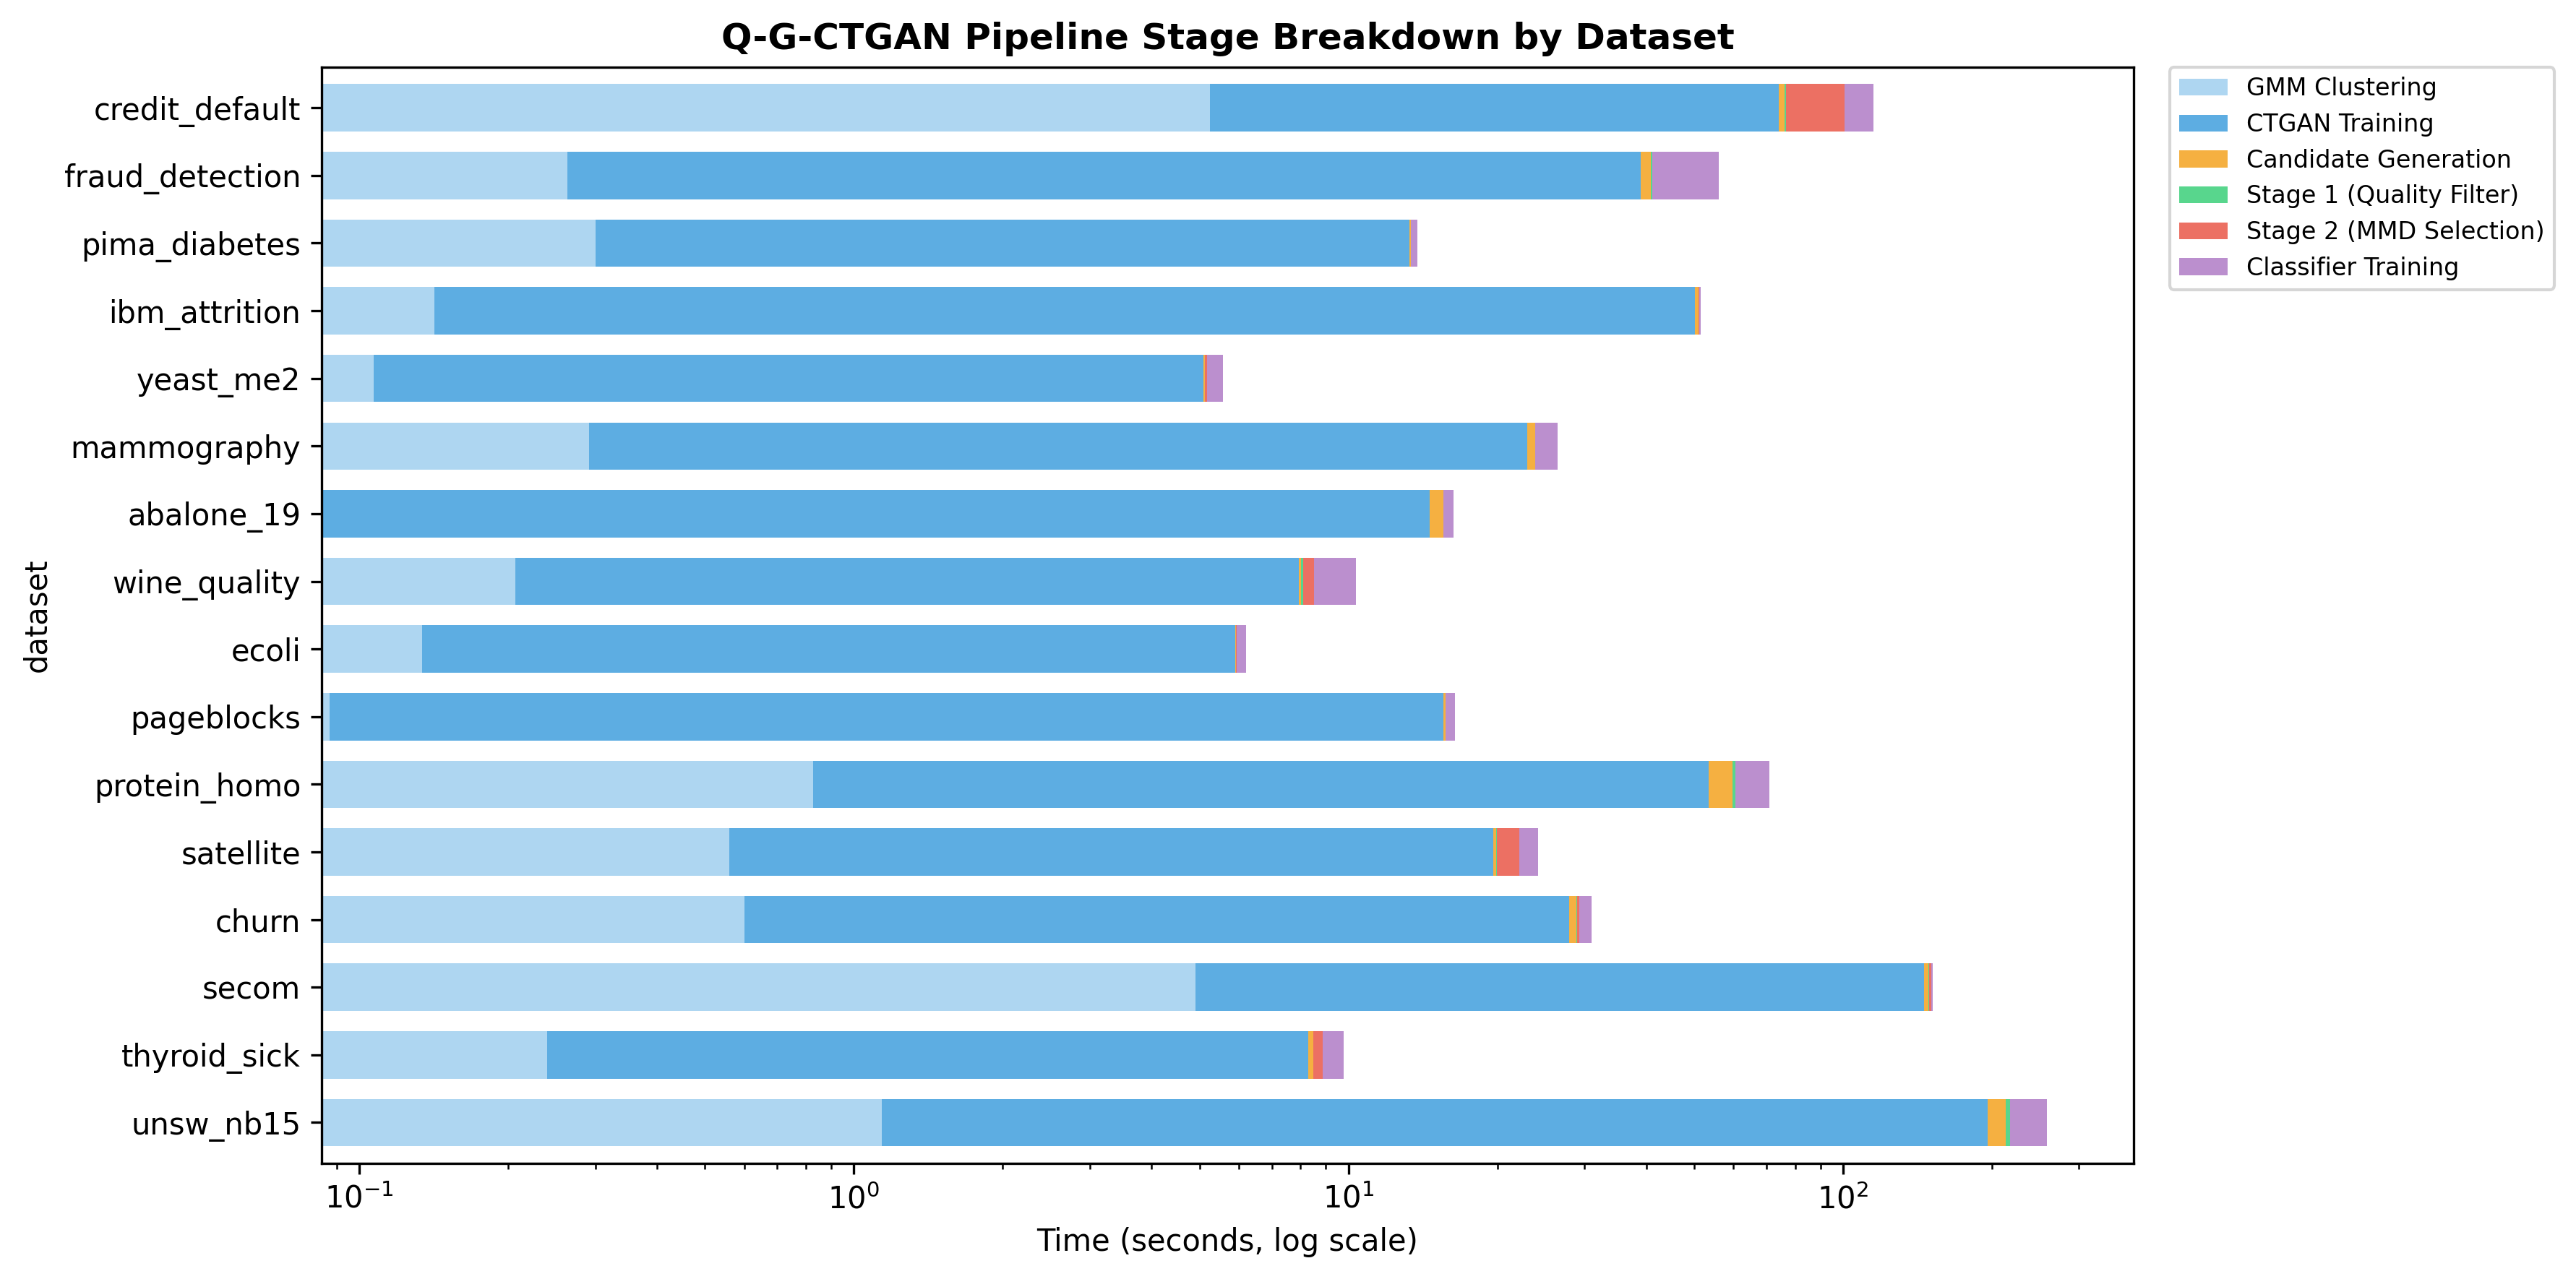

Saved: 07_stage_breakdown.png / .pdf


In [8]:
# ════════════════════════════════════════════════════════════
## 5. Q-G-CTGAN Pipeline Stage Breakdown
# ════════════════════════════════════════════════════════════
# Directly addresses R1-6: shows where Q-G-CTGAN's computational cost
# is concentrated (CTGAN training dominates; the proposed quality
# filtering stages -- Stage 1, Stage 2 -- add comparatively little
# overhead).

stage_cols = ["gmm_time_sec", "ctgan_train_time_sec", "candidate_gen_time_sec",
              "stage1_time_sec", "stage2_time_sec", "classifier_time_sec"]
stage_labels = {
    "gmm_time_sec": "GMM Clustering",
    "ctgan_train_time_sec": "CTGAN Training",
    "candidate_gen_time_sec": "Candidate Generation",
    "stage1_time_sec": "Stage 1 (Quality Filter)",
    "stage2_time_sec": "Stage 2 (MMD Selection)",
    "classifier_time_sec": "Classifier Training",
}

stage_breakdown = df_03_time.set_index("dataset")[stage_cols].reindex(DATASET_ORDER)
stage_breakdown = stage_breakdown.rename(columns=stage_labels)
stage_breakdown["Total"] = stage_breakdown.sum(axis=1)

print("\n" + "=" * 100)
print("Table: Q-G-CTGAN pipeline stage breakdown (seconds, adaptive alpha + MMD ON)")
print("=" * 100)
print(stage_breakdown.round(2).to_string())
stage_breakdown.round(2).to_csv(os.path.join(RESULTS_DIR, "07_qgctgan_stage_breakdown.csv"))

# Percentage of total time spent in each stage, averaged across datasets
stage_pct = stage_breakdown[list(stage_labels.values())].div(stage_breakdown["Total"], axis=0) * 100
print("\nAverage % of total pipeline time per stage (across all datasets):")
print(stage_pct.mean().round(1).sort_values(ascending=False).to_string())


# ---- Visualization: stacked bar chart of stage breakdown ----
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#AED6F1", "#5DADE2", "#F5B041", "#58D68D", "#EC7063", "#BB8FCE"]
stage_breakdown[list(stage_labels.values())].plot(
    kind="barh", stacked=True, ax=ax, color=colors, width=0.7
)
ax.set_xlabel("Time (seconds, log scale)", fontsize=10)
ax.set_xscale("log")
ax.set_title("Q-G-CTGAN Pipeline Stage Breakdown by Dataset", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, borderaxespad=0)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "07_stage_breakdown.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(RESULTS_DIR, "07_stage_breakdown.pdf"), bbox_inches="tight")
plt.show()
print("Saved: 07_stage_breakdown.png / .pdf")


Table: Combined runtime per dataset x method (seconds; CTAB-GAN+ 'N/A' = excluded, see Notebook 04c)
method           ADASYN  CTAB-GAN+  CTGAN-MOS  G-SMOTE  K-means CTGAN   None  Q-G-CTGAN   SMOTE   ctdGAN
dataset                                                                                                 
credit_default     78.7     1647.3      103.8     88.7           92.7   56.7      115.1    87.6    751.1
fraud_detection   201.7        N/A      133.2    294.4           85.4   90.3       56.1   189.5   7689.3
pima_diabetes       2.9       22.1        7.0      3.0           38.0    2.4       13.8     2.9     22.4
ibm_attrition       1.7       51.2       18.1      2.1           76.3    1.6       51.5     1.7     43.8
yeast_me2           4.9       18.2        7.6      4.2            8.6    3.6        5.6     4.8     30.2
mammography        23.7      214.5        8.3     26.1           13.9    7.0       26.5    20.0    239.6
abalone_19          7.7       72.5        6.5      9.2    

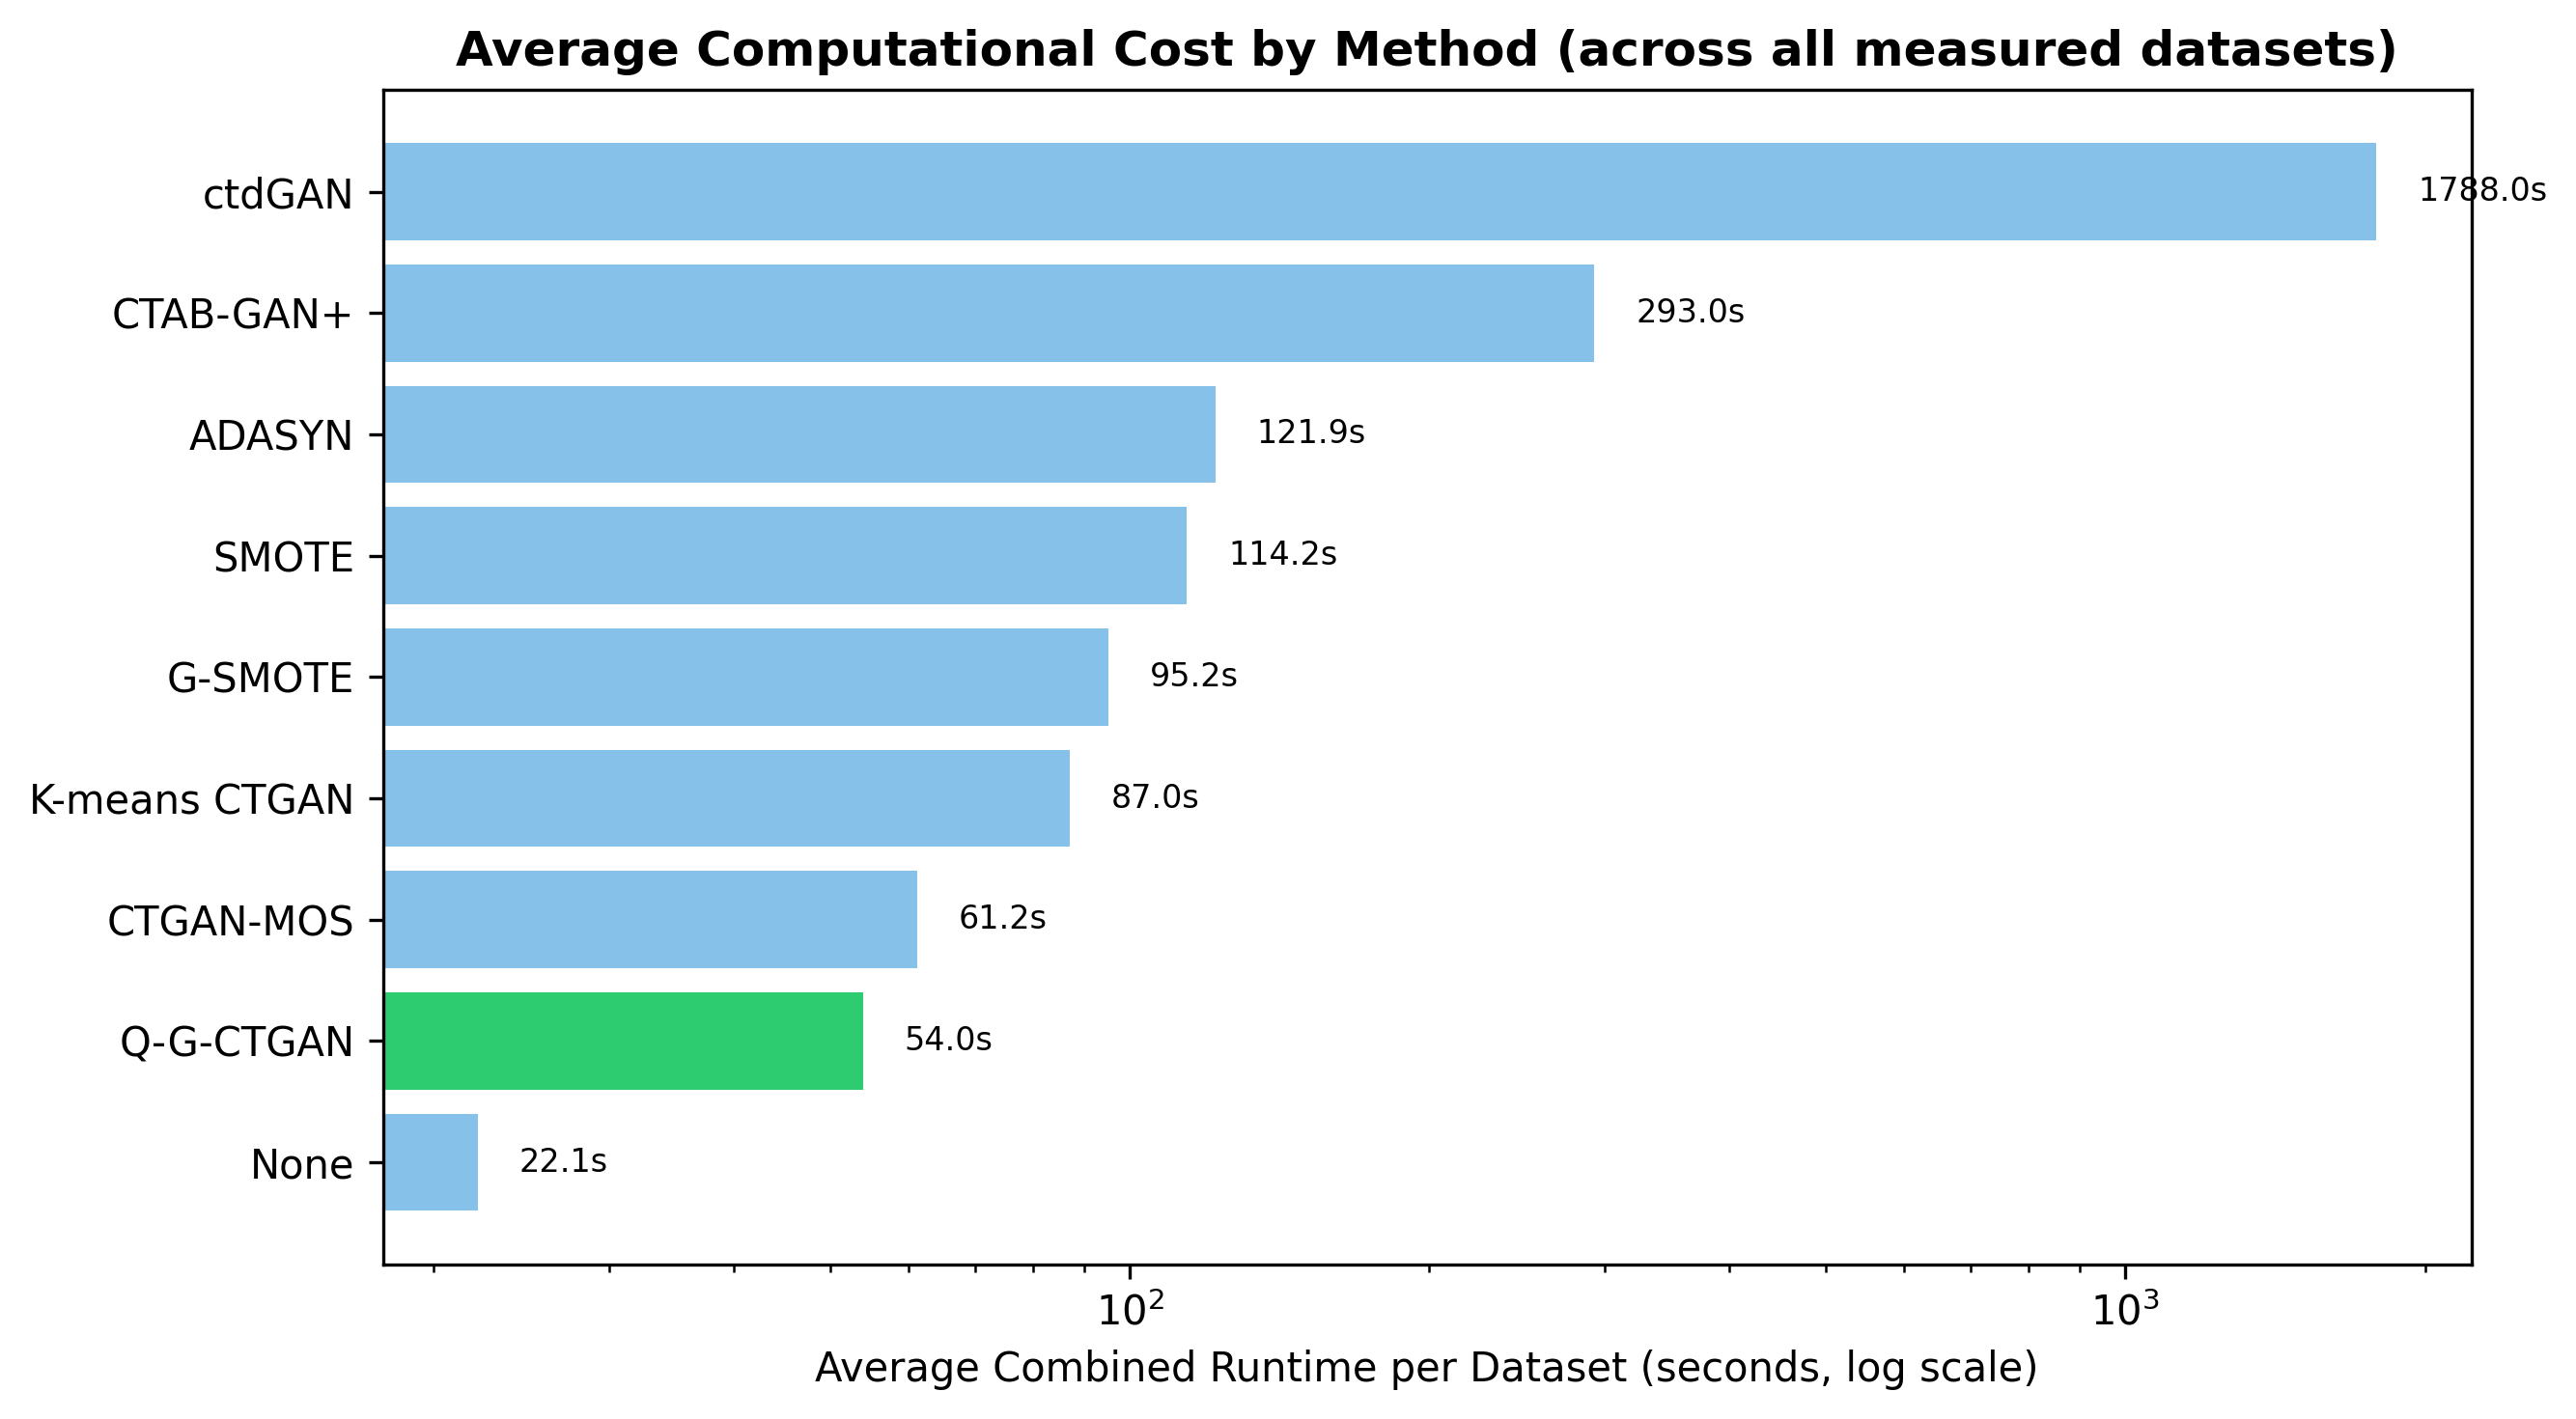

Saved: 07_method_avg_runtime.png / .pdf


In [5]:
# ════════════════════════════════════════════════════════════
## 6. Cross-Method Comparison (all 9 methods, log scale)
# ════════════════════════════════════════════════════════════

pivot_time = measured.pivot_table(index="dataset", columns="method",
                                    values="combined_time_sec", aggfunc="mean")
pivot_time = pivot_time.reindex(DATASET_ORDER)
pivot_time = pivot_time.rename(columns=METHOD_LABELS)

# Append projected CTAB-GAN+ values (marked separately) for the 3 excluded datasets
for _, row in CTABGAN_PROJECTED.iterrows():
    if "CTAB-GAN+" in pivot_time.columns:
        pivot_time.loc[row["dataset"], "CTAB-GAN+"] = np.nan  # keep measured cell empty
    else:
        pivot_time["CTAB-GAN+"] = np.nan

print("\n" + "=" * 130)
print("Table: Combined runtime per dataset x method (seconds; CTAB-GAN+ 'N/A' = excluded, see Notebook 04c)")
print("=" * 130)
print(pivot_time.round(1).to_string(na_rep="N/A"))
pivot_time.round(1).to_csv(os.path.join(RESULTS_DIR, "07_runtime_matrix.csv"))

# ---- Visualization: log-scale bar chart, average runtime per method ----
method_avg = measured.groupby("method")["combined_time_sec"].mean().rename(index=METHOD_LABELS).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#2ECC71" if m == "Q-G-CTGAN" else "#85C1E9" for m in method_avg.index]
ax.barh(method_avg.index, method_avg.values, color=colors_bar)
ax.set_xscale("log")
ax.set_xlabel("Average Combined Runtime per Dataset (seconds, log scale)", fontsize=10)
ax.set_title("Average Computational Cost by Method (across all measured datasets)",
             fontsize=12, fontweight="bold")
for i, v in enumerate(method_avg.values):
    ax.text(v * 1.1, i, f"{v:.1f}s", va="center", fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "07_method_avg_runtime.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(RESULTS_DIR, "07_method_avg_runtime.pdf"), bbox_inches="tight")
plt.show()
print("Saved: 07_method_avg_runtime.png / .pdf")

In [6]:
# ════════════════════════════════════════════════════════════
## 7. Scalability on Large Datasets (protein_homo, unsw_nb15,
##    fraud_detection) -- summarizes why CTAB-GAN+ was excluded and
##    how the other generative methods compare on the same datasets
# ════════════════════════════════════════════════════════════

LARGE_DATASETS = ["fraud_detection", "protein_homo", "unsw_nb15"]

large_comparison = timing_unified[timing_unified["dataset"].isin(LARGE_DATASETS)].copy()
large_comparison["method_label"] = large_comparison["method"].replace(METHOD_LABELS)
large_pivot = large_comparison.pivot_table(
    index="dataset", columns="method_label", values="combined_time_sec", aggfunc="mean"
)
large_pivot_hours = (large_pivot / 3600).round(2)

print("\n" + "=" * 110)
print("Table: Runtime on the 3 largest datasets (hours; CTAB-GAN+ values are PROJECTED, not measured)")
print("=" * 110)
print(large_pivot_hours.to_string(na_rep="N/A"))
large_pivot_hours.to_csv(os.path.join(RESULTS_DIR, "07_large_dataset_scalability.csv"))

print("\n07_computational_efficiency complete.")


Table: Runtime on the 3 largest datasets (hours; CTAB-GAN+ values are PROJECTED, not measured)
method_label     ADASYN  CTAB-GAN+  CTGAN-MOS  G-SMOTE  K-means CTGAN  None  Q-G-CTGAN  SMOTE  ctdGAN
dataset                                                                                              
fraud_detection    0.06      42.30       0.04     0.08           0.02  0.03       0.02   0.05    2.14
protein_homo       0.03      21.65       0.03     0.03           0.03  0.01       0.02   0.03    1.67
unsw_nb15          0.42      26.04       0.09     0.26           0.18  0.03       0.07   0.38    3.57

07_computational_efficiency complete.
